# Tutorial 2: Time-Series Analysis and Remaining Useful Life (RUL) Prediction

**Dataset:** NASA CMAPSS Turbofan Engine Degradation Simulation (FD001 subset)  
**Reference:** Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008).  
*Damage propagation modeling for aircraft engine run-to-failure simulation.*  
1st IEEE IPHM Conference. DOI: 10.1109/IPHM.2008.4906584  
**Source:** https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/

## Learning Objectives
- Understand multivariate time-series structure from degradation data
- Compute and visualise rolling statistics (moving average, rolling std dev) for anomaly hints
- Construct Remaining Useful Life (RUL) targets
- Train regression models to predict RUL from sensor readings
- Understand survival/degradation curves in the engineering context

## Dataset Description
Each engine (unit) runs from healthy state to failure. 21 sensor readings are recorded per cycle.  
FD001: Single operating condition, one failure mode (HPC degradation).  
We predict: **how many cycles remain until failure** (RUL).

## 1. Setup and Data Loading

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

In [23]:
import zipfile

# -----------------------------------------------------------------------
# Dataset: NASA CMAPSS Turbofan Engine Degradation Simulation
# Reference: Saxena, A., Goebel, K., Simon, D., Eklund, N. (2008).
#   'Damage Propagation Modeling for Aircraft Engine Run-to-Failure
#    Simulation'. Proc. 1st Int. Conf. on Prognostics and Health
#    Management (PHM08), Denver CO. DOI:10.1109/IPHM.2008.4906584
# Source: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps
#
# The dataset contains four sub-datasets (FD001–FD004), each from a
# simulated fleet of turbofan engines run to failure under controlled
# conditions. We use FD001 (simplest case):
#   - 100 training engines, 100 test engines
#   - Single operating condition (sea level)
#   - Single fault mode: High Pressure Compressor (HPC) degradation
#
# File format: 26 space-separated columns, no header
#   Col  1    : unit number
#   Col  2    : time (cycles)
#   Cols 3-5  : operational settings 1–3
#   Cols 6-26 : sensor measurements 1–21
#
# Zip structure: all files are under CMaps/ subfolder.
# -----------------------------------------------------------------------

ZIP_PATH = 'data/NASA_TurboFan_JetEngine_Dataset_Kaggle.zip'
TRAIN_FILE_IN_ZIP = 'CMaps/train_FD001.txt'

index_cols   = ['unit', 'cycle']
setting_cols = ['op1', 'op2', 'op3']
sensor_cols  = [f's{i}' for i in range(1, 22)]  # 21 sensors
all_cols     = index_cols + setting_cols + sensor_cols  # 26 total


def load_cmapss_from_zip(zip_path, internal_path):
    """Load a CMAPSS txt file directly from inside the zip archive."""
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(internal_path) as f:
            df = pd.read_csv(f, sep=r'\s+', header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    assert df.shape[1] == 26, f'Expected 26 columns, got {df.shape[1]}'
    df.columns = all_cols
    return df


df_train = load_cmapss_from_zip(ZIP_PATH, TRAIN_FILE_IN_ZIP)
print(f'Loaded: {TRAIN_FILE_IN_ZIP}  shape={df_train.shape}')
df_train.head()

Loaded: CMaps/train_FD001.txt  shape=(20631, 26)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Constructing the RUL Target

RUL for a given cycle of a given unit = (max cycle of that unit) − (current cycle).  
At the last cycle, RUL = 0 (failure).

In [24]:
max_cycles = df_train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

df_train = df_train.merge(max_cycles, on='unit')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']

# Piecewise-linear RUL cap: beyond 125 cycles from EOL, treat as 125 (common in literature)
# This prevents the model from over-fitting to early healthy cycles.
RUL_CAP = 125
df_train['RUL_capped'] = df_train['RUL'].clip(upper=RUL_CAP)

print(f"Number of engine units: {df_train['unit'].nunique()}")
print(f"Total observations: {len(df_train)}")
df_train[['unit', 'cycle', 'RUL', 'RUL_capped']].head(10)

Number of engine units: 100
Total observations: 20631


,unit,cycle,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


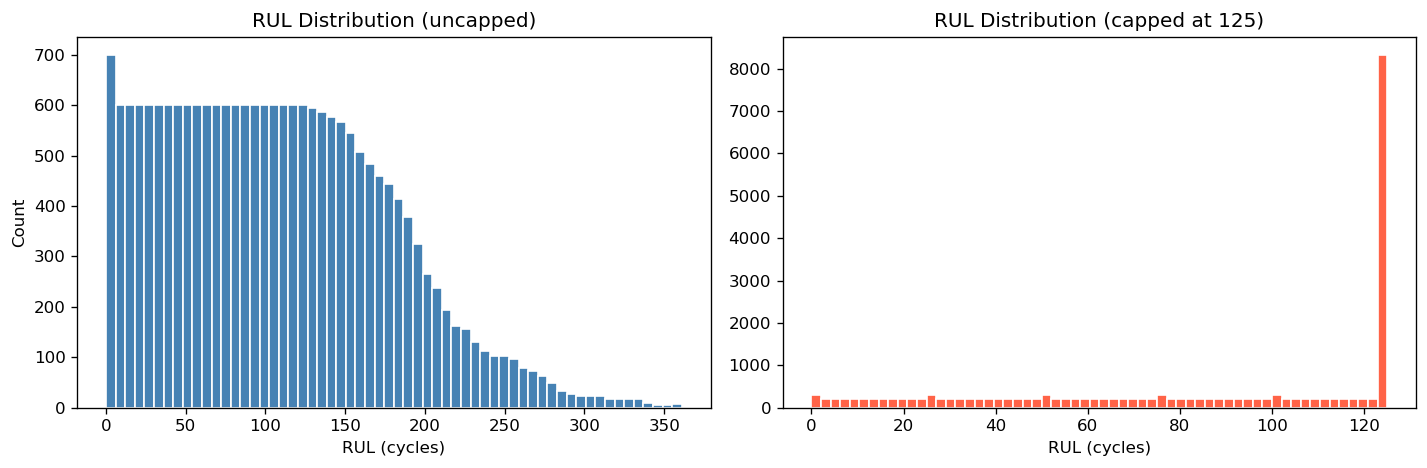

In [25]:
# RUL distribution across all observations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['RUL'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')
axes[0].set_title('RUL Distribution (uncapped)')

axes[1].hist(df_train['RUL_capped'], bins=60, color='tomato', edgecolor='white')
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_title('RUL Distribution (capped at 125)')

plt.tight_layout()
plt.show()

## 3. Time-Series Exploration

We inspect a few sensor signals over the life of individual engines to observe degradation trends.

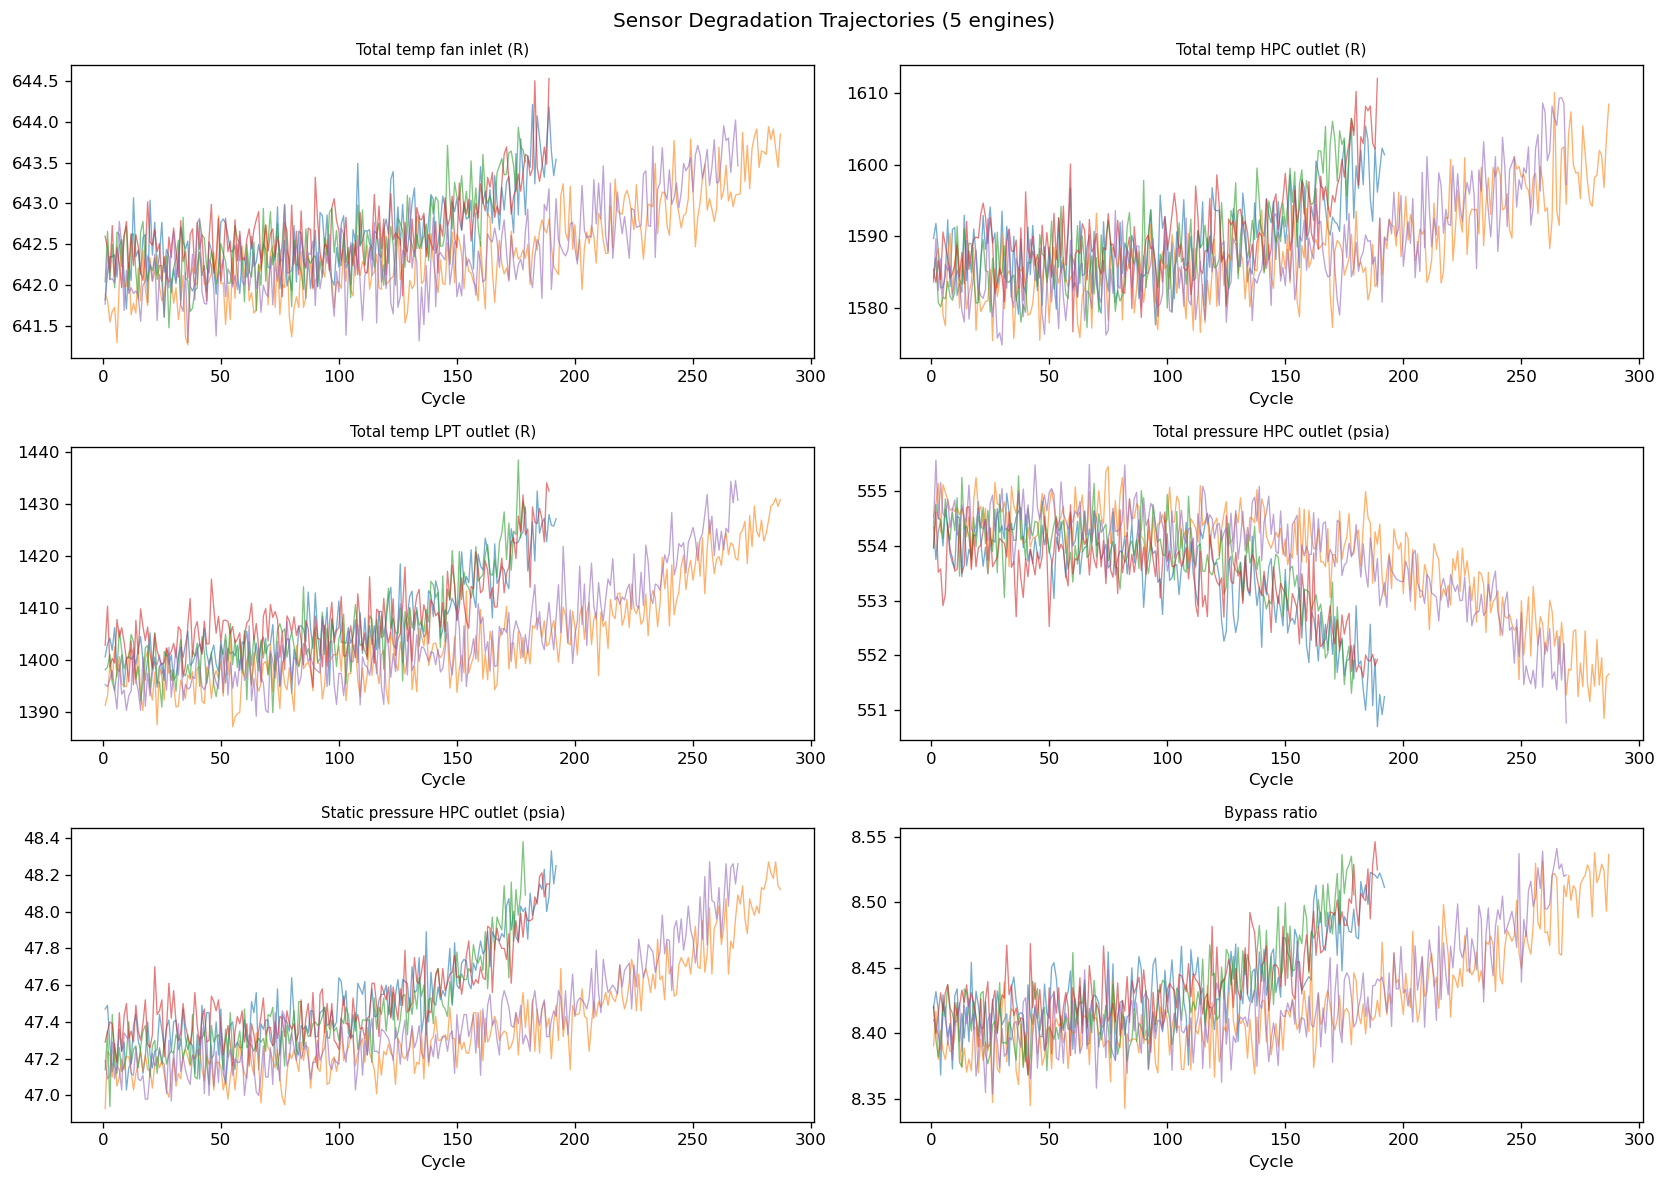

In [26]:
# Plot sensor trajectories for 5 randomly sampled engine units
informative_sensors = ['s2', 's3', 's4', 's7', 's11', 's15']
sensor_names = {
    's2': 'Total temp fan inlet (R)',
    's3': 'Total temp HPC outlet (R)',
    's4': 'Total temp LPT outlet (R)',
    's7': 'Total pressure HPC outlet (psia)',
    's11': 'Static pressure HPC outlet (psia)',
    's15': 'Bypass ratio'
}

sample_units = df_train['unit'].unique()[:5]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(informative_sensors):
    for unit in sample_units:
        sub = df_train[df_train['unit'] == unit].sort_values('cycle')
        axes[i].plot(sub['cycle'], sub[sensor], alpha=0.6, linewidth=0.8)
    axes[i].set_title(sensor_names[sensor], fontsize=9)
    axes[i].set_xlabel('Cycle')

plt.suptitle('Sensor Degradation Trajectories (5 engines)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Rolling Statistics

Rolling (windowed) statistics smooth noisy sensor signals and reveal trend information.  
- **Rolling mean**: trend direction
- **Rolling standard deviation**: increasing variability often indicates approaching failure

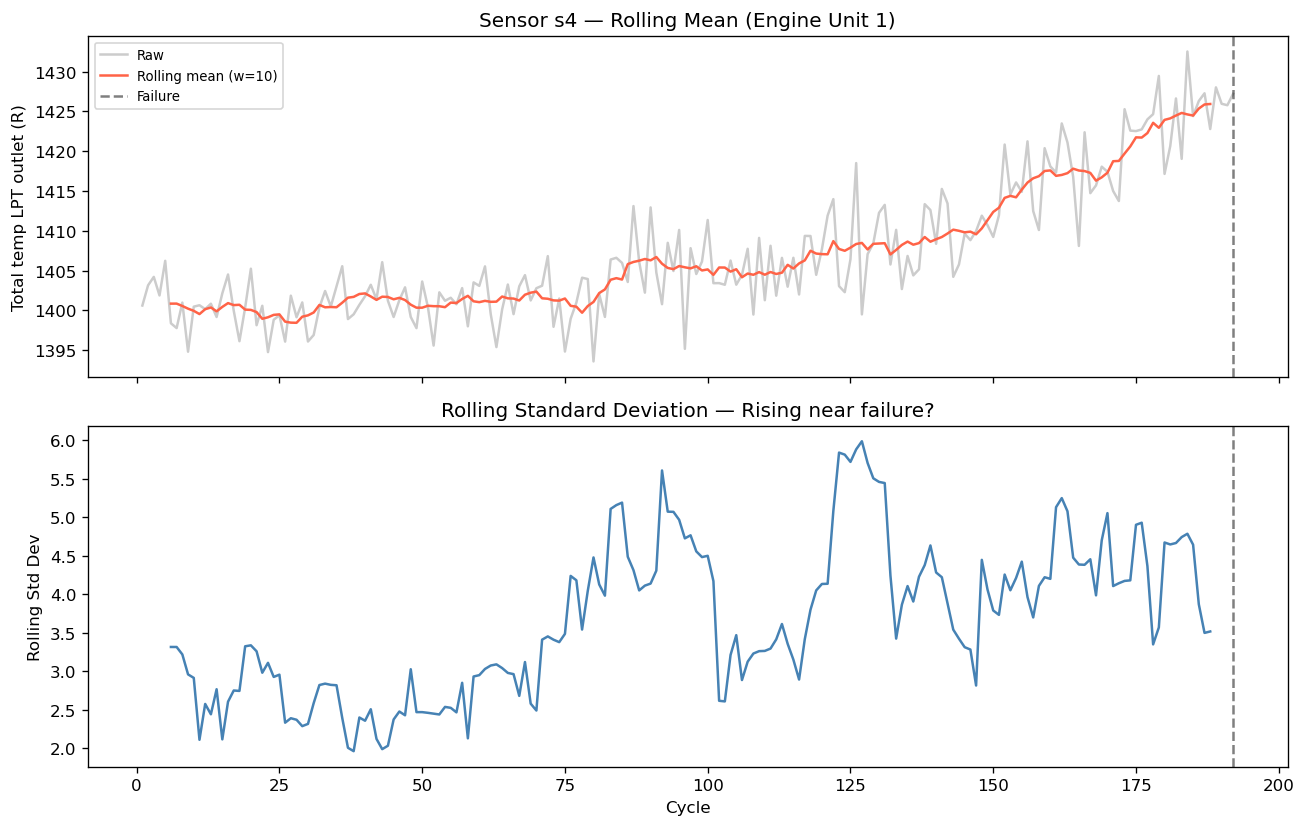

In [27]:
# Focus on unit 1
u1 = df_train[df_train['unit'] == 1].sort_values('cycle').copy()

window = 10
sensor = 's4'

u1['roll_mean'] = u1[sensor].rolling(window=window, center=True).mean()
u1['roll_std'] = u1[sensor].rolling(window=window, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(u1['cycle'], u1[sensor], alpha=0.4, color='grey', label='Raw')
axes[0].plot(u1['cycle'], u1['roll_mean'], color='tomato', label=f'Rolling mean (w={window})')
axes[0].axvline(u1['cycle'].max(), color='black', linestyle='--', alpha=0.5, label='Failure')
axes[0].set_ylabel(sensor_names[sensor])
axes[0].legend(fontsize=8)
axes[0].set_title('Sensor s4 — Rolling Mean (Engine Unit 1)')

axes[1].plot(u1['cycle'], u1['roll_std'], color='steelblue')
axes[1].axvline(u1['cycle'].max(), color='black', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Rolling Std Dev')
axes[1].set_xlabel('Cycle')
axes[1].set_title('Rolling Standard Deviation — Rising near failure?')

plt.tight_layout()
plt.show()

## 5. Feature Engineering for RUL Prediction

We compute per-unit rolling features to give models temporal context.  
Features added: rolling mean and rolling std dev over a window for each sensor.

In [28]:
# Remove sensors with near-zero variance (constant across cycles — uninformative)
sensor_var = df_train[sensor_cols].var()
informative = sensor_var[sensor_var > 0.1].index.tolist()
print(f"Informative sensors ({len(informative)}): {informative}")

Informative sensors (8): ['s2', 's3', 's4', 's7', 's9', 's12', 's14', 's17']


In [29]:
WINDOW = 15

def add_rolling_features(df, sensors, window):
    df = df.copy().sort_values(['unit', 'cycle'])
    for s in sensors:
        df[f'{s}_rmean'] = (
            df.groupby('unit')[s]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f'{s}_rstd'] = (
            df.groupby('unit')[s]
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
    return df

df_feat = add_rolling_features(df_train, informative, WINDOW)
print("Feature shape after rolling:", df_feat.shape)

Feature shape after rolling: (20631, 45)


In [30]:
# Assemble final feature matrix
roll_cols = [c for c in df_feat.columns if '_rmean' in c or '_rstd' in c]
feature_cols = informative + roll_cols

X = df_feat[feature_cols].values
y = df_feat['RUL_capped'].values

# Train/test split at the unit level to avoid data leakage
units = df_feat['unit'].unique()
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

train_mask = df_feat['unit'].isin(train_units)
test_mask = df_feat['unit'].isin(test_units)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16561, 24), Test: (4070, 24)


## 6. RUL Regression Models

**Ridge Regression**: regularised linear model (L2 penalty).  
**Gradient Boosted Trees**: non-linear ensemble, state-of-the-art for tabular data.  

Metrics:
- RMSE (Root Mean Squared Error) — penalises large errors
- MAE (Mean Absolute Error) — average absolute deviation
- R² — proportion of variance explained

In [31]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

gbr = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gbr.fit(X_train, y_train)

print("Models trained.")

Models trained.


In [32]:
def eval_regression(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_pred = np.clip(y_pred, 0, None)  # RUL >= 0
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    print(f"{name:30s}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    return y_pred

pred_ridge = eval_regression(ridge, X_test, y_test, 'Ridge Regression')
pred_gbr = eval_regression(gbr, X_test, y_test, 'Gradient Boosted Trees')

Ridge Regression                RMSE=20.02  MAE=16.04  R²=0.7697
Gradient Boosted Trees          RMSE=16.91  MAE=12.14  R²=0.8356


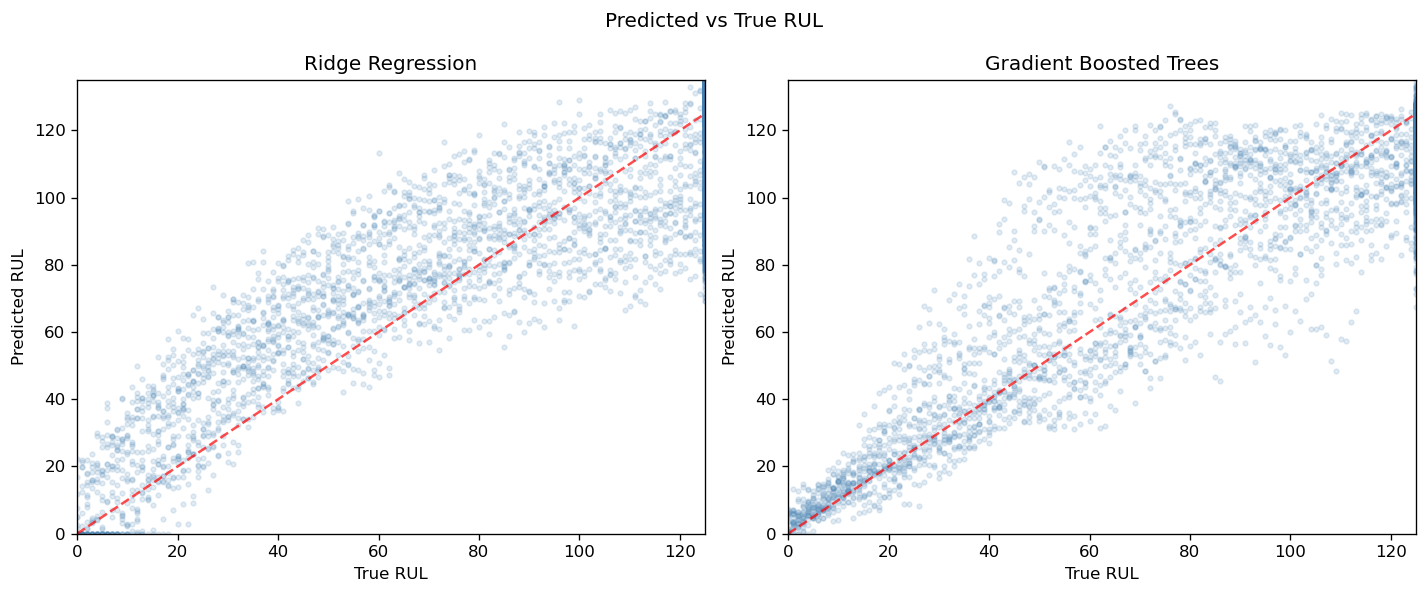

In [33]:
# Predicted vs actual RUL scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name in [
    (axes[0], pred_ridge, 'Ridge Regression'),
    (axes[1], pred_gbr, 'Gradient Boosted Trees')
]:
    ax.scatter(y_test, pred, alpha=0.15, s=8, color='steelblue')
    lims = [0, RUL_CAP]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(name)
    ax.set_xlim(lims)
    ax.set_ylim([0, RUL_CAP + 10])

plt.suptitle('Predicted vs True RUL', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Degradation Trajectories with Predicted RUL

We visualise how GBR-predicted RUL evolves over the life of a single test engine.

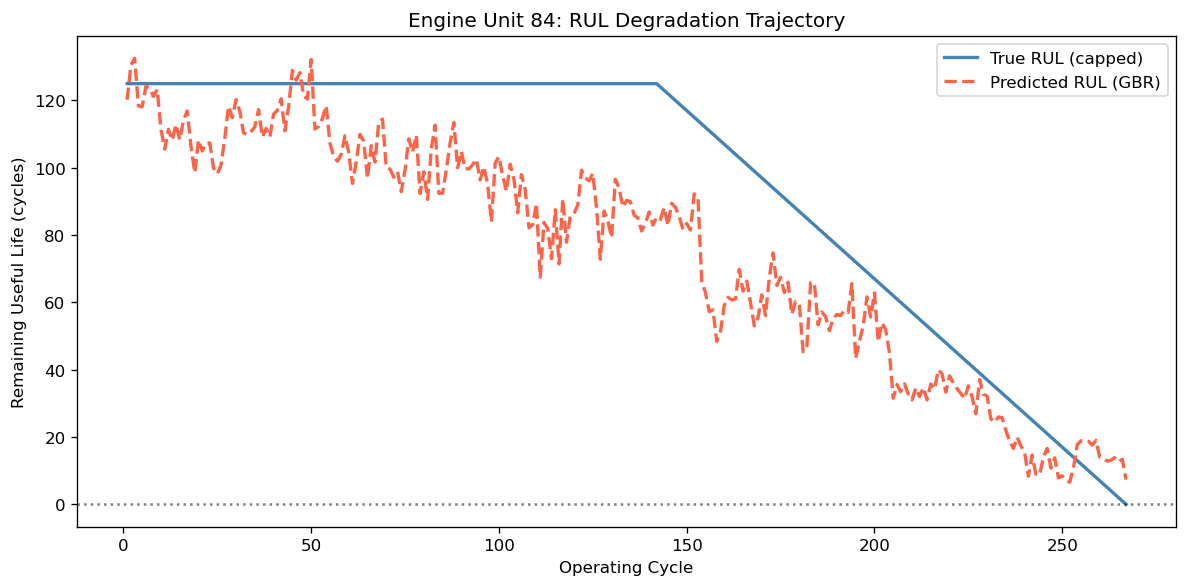

In [34]:
# Select a test unit and plot predicted vs true RUL over cycles
test_unit_id = test_units[0]
test_unit_data = df_feat[df_feat['unit'] == test_unit_id].sort_values('cycle').copy()

X_unit = scaler.transform(test_unit_data[feature_cols].values)
pred_unit = np.clip(gbr.predict(X_unit), 0, None)

plt.figure(figsize=(10, 5))
plt.plot(test_unit_data['cycle'], test_unit_data['RUL_capped'],
         color='steelblue', label='True RUL (capped)', linewidth=2)
plt.plot(test_unit_data['cycle'], pred_unit,
         color='tomato', linestyle='--', label='Predicted RUL (GBR)', linewidth=2)
plt.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.xlabel('Operating Cycle')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title(f'Engine Unit {test_unit_id}: RUL Degradation Trajectory')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Early Warning: Cycle at Which Predicted RUL Falls Below a Threshold

In practice, maintenance decisions are triggered when predicted RUL falls below a safety threshold.  
We compute for each test engine: at which cycle does predicted RUL first drop below 30 cycles?

In [35]:
THRESHOLD = 30

warnings = []
for unit in test_units[:20]:  # first 20 test units for clarity
    sub = df_feat[df_feat['unit'] == unit].sort_values('cycle')
    X_u = scaler.transform(sub[feature_cols].values)
    pred_u = np.clip(gbr.predict(X_u), 0, None)
    true_rul = sub['RUL'].values

    # Cycle at which predicted RUL < threshold
    warn_idx = np.where(pred_u < THRESHOLD)[0]
    warn_cycle = sub['cycle'].values[warn_idx[0]] if len(warn_idx) > 0 else None

    # True last cycle
    last_cycle = sub['cycle'].max()

    warnings.append({
        'unit': unit,
        'last_cycle': last_cycle,
        'warn_cycle': warn_cycle,
        'early_warning_cycles': (last_cycle - warn_cycle) if warn_cycle else None
    })

warn_df = pd.DataFrame(warnings)
print(warn_df.to_string(index=False))

 unit  last_cycle  warn_cycle  early_warning_cycles
   84         267         227                    40
   54         257         217                    40
   71         208         183                    25
   46         256         225                    31
   45         158         145                    13
   40         188         152                    36
   23         168         129                    39
   81         240         207                    33
   11         240         206                    34
    1         192         174                    18
   19         158         121                    37
   31         234         210                    24
   74         166         150                    16
   34         195         166                    29
   91         135          99                    36
    5         269         237                    32
   77         154         137                    17
   78         231         211                    20
   13       

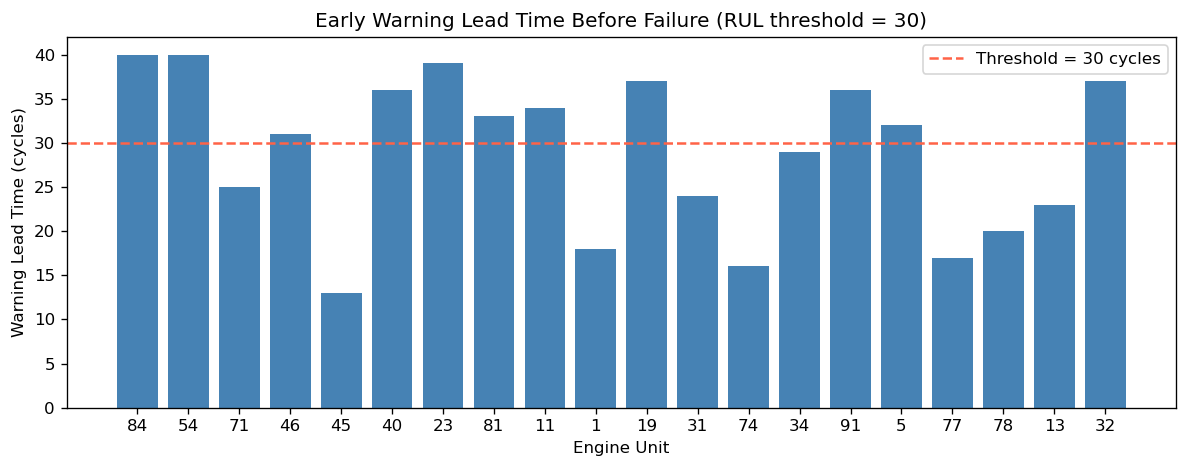

In [36]:
valid = warn_df.dropna(subset=['early_warning_cycles'])

plt.figure(figsize=(10, 4))
plt.bar(valid['unit'].astype(str), valid['early_warning_cycles'], color='steelblue')
plt.axhline(THRESHOLD, color='tomato', linestyle='--', label=f'Threshold = {THRESHOLD} cycles')
plt.xlabel('Engine Unit')
plt.ylabel('Warning Lead Time (cycles)')
plt.title(f'Early Warning Lead Time Before Failure (RUL threshold = {THRESHOLD})')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance for RUL (GBR)

Which sensors (raw and rolling) contribute most to RUL prediction?

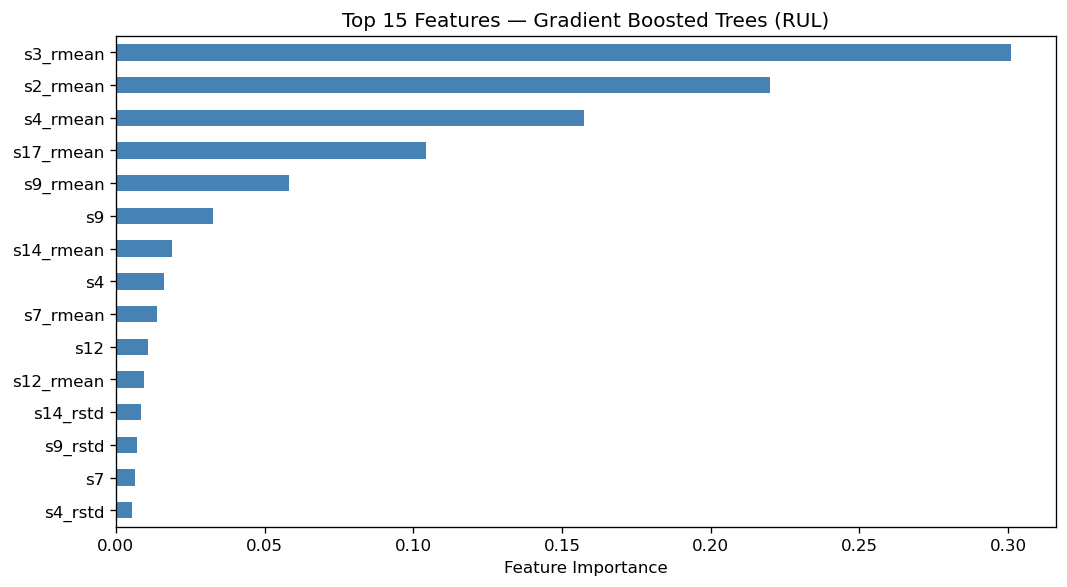

In [37]:
feat_imp = pd.Series(gbr.feature_importances_, index=feature_cols)
feat_imp_top = feat_imp.nlargest(15)

plt.figure(figsize=(9, 5))
feat_imp_top.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Features — Gradient Boosted Trees (RUL)')
plt.tight_layout()
plt.show()

## Summary

- The CMAPSS dataset captures degradation of turbofan engines: sensor signals drift over time as the engine degrades.
- Rolling features (windowed mean and std dev) substantially improve RUL prediction by providing local trend information.
- Gradient Boosted Trees outperform Ridge Regression, as expected on structured non-linear sensor data.
- The early-warning analysis shows we can predict impending failure tens of cycles in advance — enabling proactive maintenance scheduling.

## Further Directions
- **LSTM / Temporal Convolutional Networks**: explicitly model sequence structure (see Li et al., 2018, *Remaining Useful Life Estimation in Prognostics Using Deep Convolution Neural Networks*, Reliability Engineering & Systems Safety)
- **Survival analysis**: frame RUL as a hazard function (Cox proportional hazards model)
- **Uncertainty quantification**: use Bayesian regression or conformal prediction to attach confidence intervals to RUL predictions

## References
- Saxena, A. et al. (2008). Damage propagation modeling for aircraft engine run-to-failure simulation. *IPHM*. IEEE. DOI: 10.1109/IPHM.2008.4906584
- Heimes, F.O. (2008). Recurrent Neural Networks for Remaining Useful Life Estimation. *IPHM*. IEEE.
- Li, X. et al. (2018). Remaining Useful Life Estimation Using Deep Convolution Neural Networks. *Reliability Engineering & Systems Safety*, 172, 1–11.